<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy_of_copy_of_copy_of_gp__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [4]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [5]:
all_reviews = []

for app_name, app_id in apps.items():
    print(f"Fetching reviews for {app_name}...")

    result, _ = reviews(
        app_id,
        lang="en",
        country="us",
        sort=Sort.NEWEST,
        count=3000
    )

    for r in result:
        all_reviews.append({
            "app_name": app_name,
            "review_text": r["content"],
            "rating": r["score"],
            "sentiment_label": label_sentiment(r["score"])
        })

Fetching reviews for Amazon...
Fetching reviews for Shein...
Fetching reviews for AliExpress...
Fetching reviews for Noon...
Fetching reviews for Trendyol...


In [6]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,"Get it fast feature, overnight shipping. 2 day...",1,Negative
1,Amazon,"it's great, love shopping from home, and retur...",5,Positive
2,Amazon,great service,5,Positive
3,Amazon,"Amazon price gouging is insane, can you stop w...",1,Negative
4,Amazon,is there an update to address app crashing?,3,Neutral


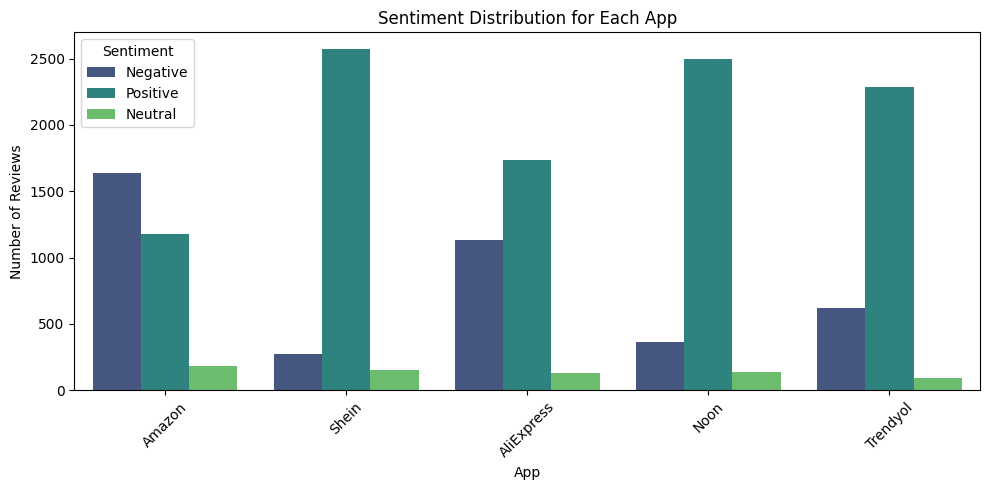

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [8]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    10264
Negative     4038
Neutral       698
Name: count, dtype: int64


In [9]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14446


In [10]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [11]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [12]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,"Get it fast feature, overnight shipping. 2 day...",get it fast feature overnight shipping days l...
1,"it's great, love shopping from home, and retur...",its great love shopping from home and returns ...
2,great service,great service
3,"Amazon price gouging is insane, can you stop w...",amazon price gouging is insane can you stop wi...
4,is there an update to address app crashing?,is there an update to address app crashing
5,Latest update ruined screenshot!!! Now it won'...,latest update ruined screenshot now it wont ev...
6,Charged twice for a monthly service I haven't ...,charged twice for a monthly service i havent u...
7,I can't install this app on my new tablet. It'...,i cant install this app on my new tablet its s...
8,good to buy from Amazon,good to buy from amazon
9,"I ordered item, they received the money, and a...",i ordered item they received the money and a f...


In [13]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [14]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,get it fast feature overnight shipping days l...,"[get, it, fast, feature, overnight, shipping, ..."
1,its great love shopping from home and returns ...,"[its, great, love, shopping, from, home, and, ..."
2,great service,"[great, service]"
3,amazon price gouging is insane can you stop wi...,"[amazon, price, gouging, is, insane, can, you,..."
4,is there an update to address app crashing,"[is, there, an, update, to, address, app, cras..."


In [15]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[get, it, fast, feature, overnight, shipping, ...","[get, fast, feature, overnight, shipping, days...","[get, fast, feature, overnight, shipping, day,..."
1,"[its, great, love, shopping, from, home, and, ...","[great, love, shopping, home, returns, easy, n...","[great, love, shopping, home, return, easy, ne..."
2,"[great, service]","[great, service]","[great, service]"
3,"[amazon, price, gouging, is, insane, can, you,...","[amazon, price, gouging, insane, stop, greed]","[amazon, price, gouging, insane, stop, greed]"
4,"[is, there, an, update, to, address, app, cras...","[update, address, app, crashing]","[update, address, app, crashing]"


In [16]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

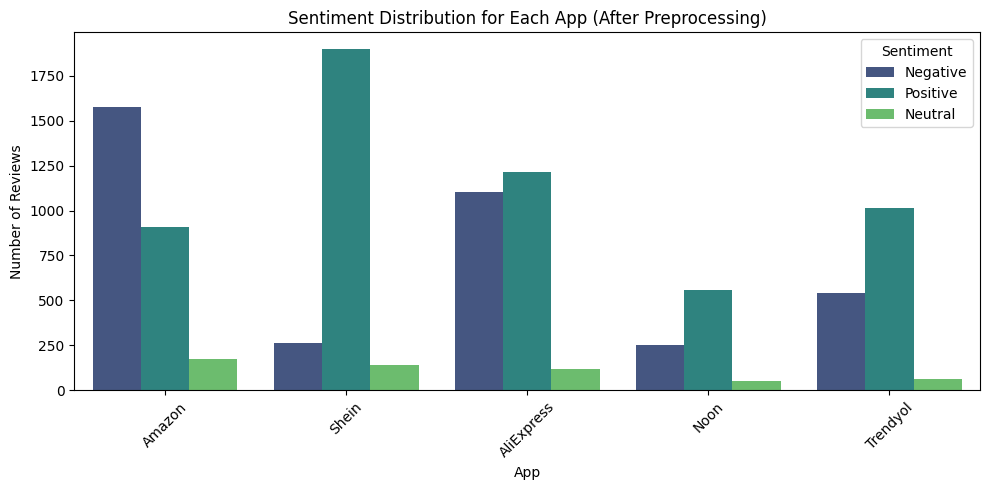

In [17]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [18]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5599
Negative    3729
Neutral      552
Name: count, dtype: int64


In [19]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [20]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.8 MB/s eta 0:00:00


In [22]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from gensim.models import Word2Vec
import numpy as np


X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def get_sentence_vector(tokens, model, vector_size):
  vectors = [model.wv[word] for word in tokens if word in model.wv]

  if len(vectors) ==0:
    return np.zeros(vector_size)

  return np.mean(vectors, axis=0)

X_train = np.array([get_sentence_vector(tokens, w2v_model, 100)for tokens in X_train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4479
Negative    2983
Neutral      442
Name: count, dtype: int64
After SMOTE: sentiment_label
Positive    4479
Neutral     4479
Negative    4479
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7667004048582996
Classification Report:
               precision    recall  f1-score   support

    Negative       0.70      0.81      0.75       746
     Neutral       0.09      0.06      0.07       110
    Positive       0.87      0.81      0.84      1120

    accuracy                           0.77      1976
   macro avg       0.55      0.56      0.55      1976
weighted avg       0.76      0.77      0.76      1976



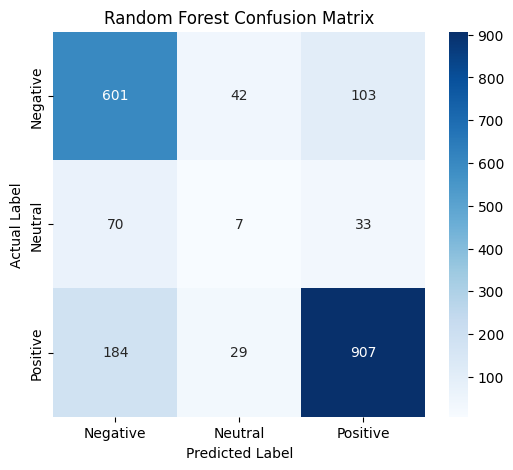

In [25]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [26]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6680161943319838

Classification Report:

              precision    recall  f1-score   support

    Negative       0.66      0.64      0.65       746
     Neutral       0.07      0.16      0.10       110
    Positive       0.82      0.73      0.77      1120

    accuracy                           0.67      1976
   macro avg       0.52      0.51      0.51      1976
weighted avg       0.72      0.67      0.69      1976

Confusion Matrix:
 [[480 122 144]
 [ 54  18  38]
 [192 106 822]]


In [27]:
# SUPPORT VECTOR MACHINE (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_SVM)

print("SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))


SVM Accuracy: 72.87 %

Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.75      0.76       746
     Neutral       0.13      0.40      0.20       110
    Positive       0.91      0.75      0.82      1120

    accuracy                           0.73      1976
   macro avg       0.61      0.63      0.59      1976
weighted avg       0.82      0.73      0.76      1976

Confusion Matrix:
 [[557 129  60]
 [ 43  44  23]
 [119 162 839]]


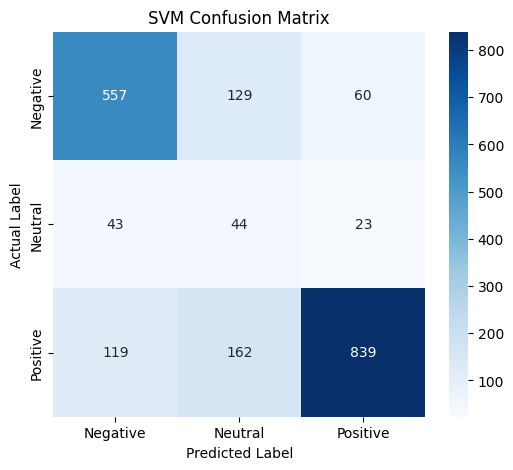

In [28]:

#  Confusion Matrix Graph FOR SVM

cm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [29]:
print(set(y_pred_SVM))

{'Positive', 'Neutral', 'Negative'}


In [30]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6417004048582996

Classification Report:
               precision    recall  f1-score   support

    Negative       0.67      0.78      0.72       746
     Neutral       0.05      0.15      0.08       110
    Positive       0.87      0.60      0.71      1120

    accuracy                           0.64      1976
   macro avg       0.53      0.51      0.50      1976
weighted avg       0.75      0.64      0.68      1976

Confusion Matrix:
 [[583  86  77]
 [ 69  17  24]
 [213 239 668]]


In [31]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:38:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8006072874493927

Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.83      0.78       746
     Neutral       0.00      0.00      0.00       110
    Positive       0.85      0.86      0.85      1120

    accuracy                           0.80      1976
   macro avg       0.53      0.56      0.55      1976
weighted avg       0.76      0.80      0.78      1976

Confusion Matrix:

[[620   0 126]
 [ 65   0  45]
 [156   2 962]]
